## Importing filters

In [1]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"
global_min = np.inf
global_max = -np.inf

for fname in os.listdir(filter_folder):
    if fname.endswith(".txt"):

        filepath = os.path.join(filter_folder, fname)
        data = np.loadtxt(filepath)

        lam_min = data[:, 0].min()
        lam_max = data[:, 0].max()

        global_min = min(global_min, lam_min)
        global_max = max(global_max, lam_max)

        print(f"{fname:20s}  {lam_min:.0f} – {lam_max:.0f} Å")

print("\nOverall wavelength coverage:")
print(f"{global_min:.0f} – {global_max:.0f} Å")

HST_ACS_WFC_F435W.txt  3526 – 4979 Å
HST_ACS_WFC_F606W.txt  4569 – 7283 Å
HST_ACS_WFC_F814W.txt  6738 – 9778 Å
HST_WFC3_IR_F105W.txt  8650 – 12250 Å
HST_WFC3_IR_F125W.txt  10640 – 14390 Å
HST_WFC3_IR_F140W.txt  11370 – 16450 Å
HST_WFC3_IR_F160W.txt  13664 – 17205 Å
JWST_NIRCam_F090W.txt  7836 – 10356 Å
JWST_NIRCam_F115W.txt  9892 – 13282 Å
JWST_NIRCam_F150W.txt  12798 – 17238 Å
JWST_NIRCam_F200W.txt  16904 – 22984 Å
JWST_NIRCam_F277W.txt  23371 – 33015 Å
JWST_NIRCam_F356W.txt  29930 – 42294 Å
JWST_NIRCam_F410M.txt  36740 – 45226 Å
JWST_NIRCam_F444W.txt  37132 – 50996 Å

Overall wavelength coverage:
3526 – 50996 Å


In [2]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"

filter_files = [
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
]

filter_files.sort()

print(filter_files)

['D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F435W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F606W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F814W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F105W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F125W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star For

## Visualising filters

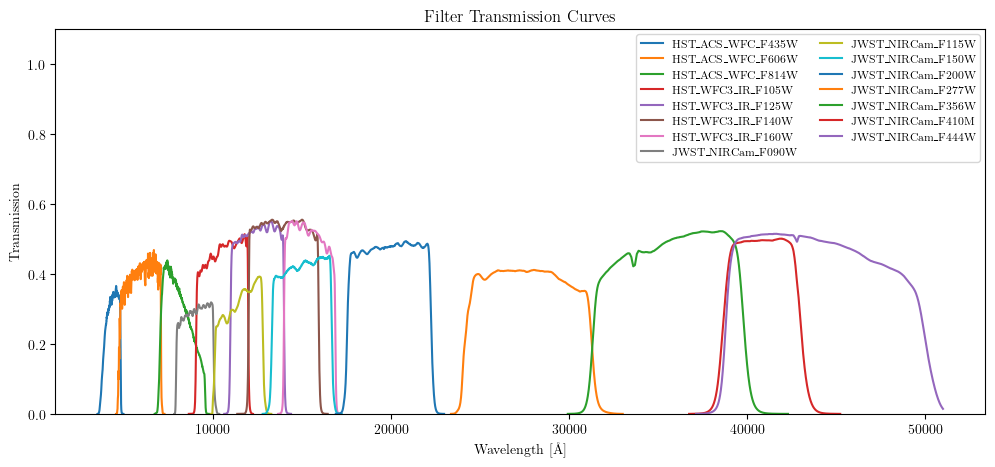

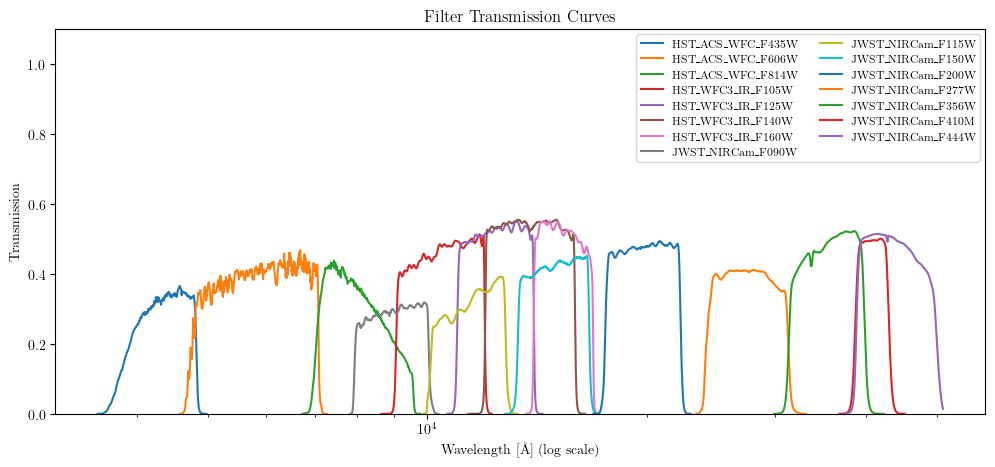

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}"
})

plt.figure(figsize=(12,5))

for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]          # wavelength in Å
    transmission = filt_data[:,1]  # 0-1 transmission
    filt_label = os.path.splitext(os.path.basename(ffile))[0]
    plt.plot(wave, transmission, label=filt_label)

plt.xlabel("Wavelength [Å]")
plt.ylabel("Transmission")
plt.title("Filter Transmission Curves")
plt.legend(fontsize=8, ncol=2)
plt.xscale('linear')
plt.ylim(0,1.1)
plt.show()

plt.figure(figsize=(12,5))

for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]          # wavelength in Å
    transmission = filt_data[:,1]  # 0-1 transmission
    filt_label = os.path.splitext(os.path.basename(ffile))[0]
    plt.plot(wave, transmission, label=filt_label)

plt.xscale('log')
plt.xlabel("Wavelength [Å] (log scale)")
plt.ylabel("Transmission")
plt.title("Filter Transmission Curves")
plt.legend(fontsize=8, ncol=2)
plt.ylim(0,1.1)
plt.show()

## Setting age ranges

In [4]:

import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200, 1100, 100)

years = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


## Defining dust and nebula

In [5]:
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2
dust["eta"] = 2. #multiplies Av - extra dust for young stars

nebular = {}   #nebular emission component
nebular["logU"] = -3.   #log_10(ionization parameter)

## Photometry for all ages

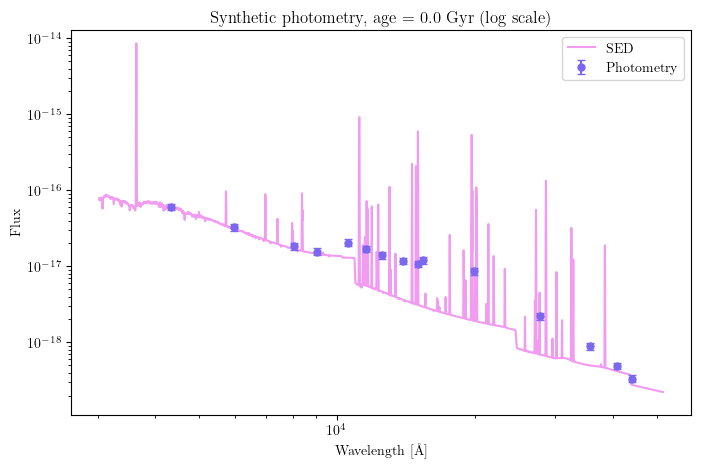

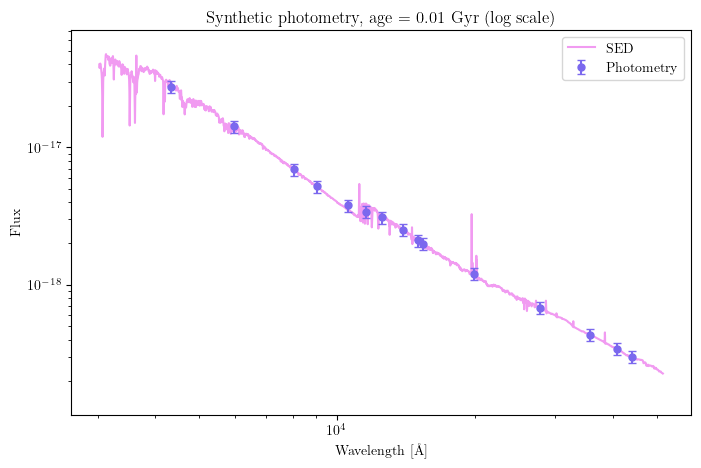

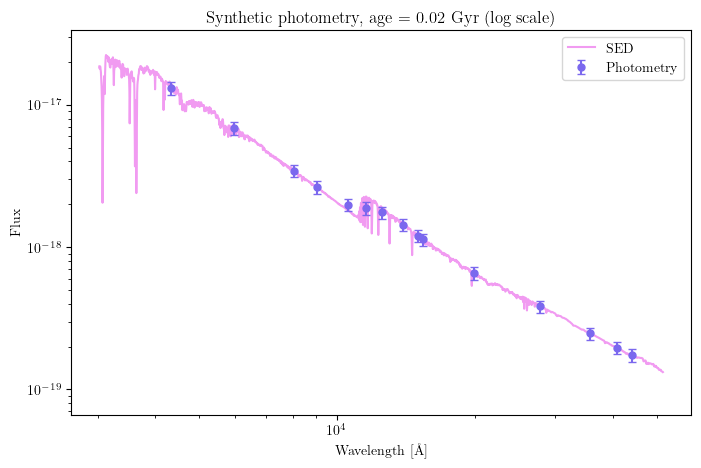

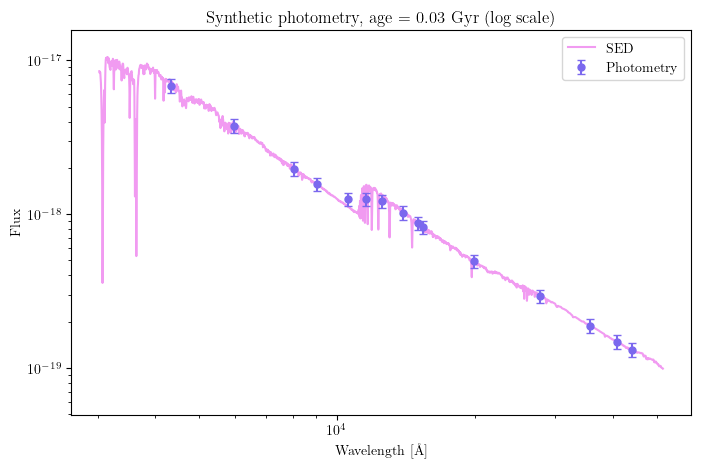

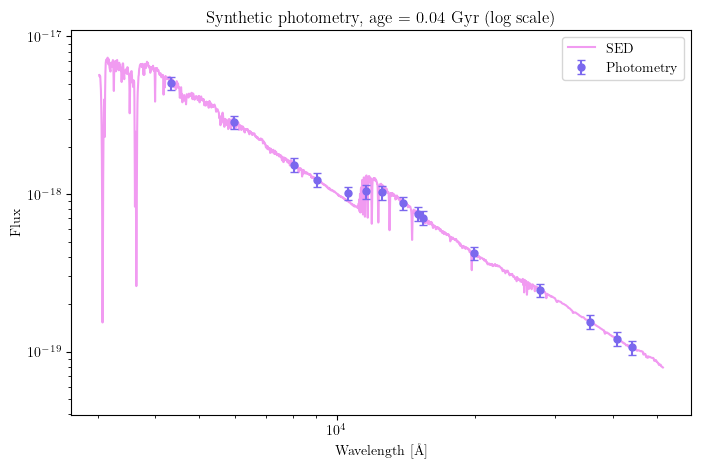

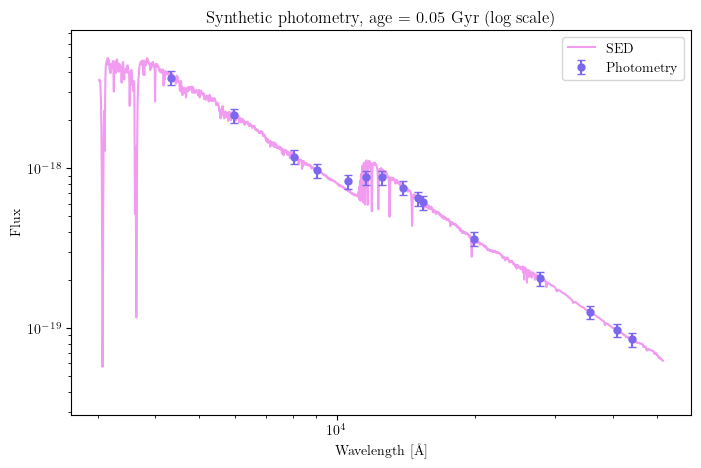

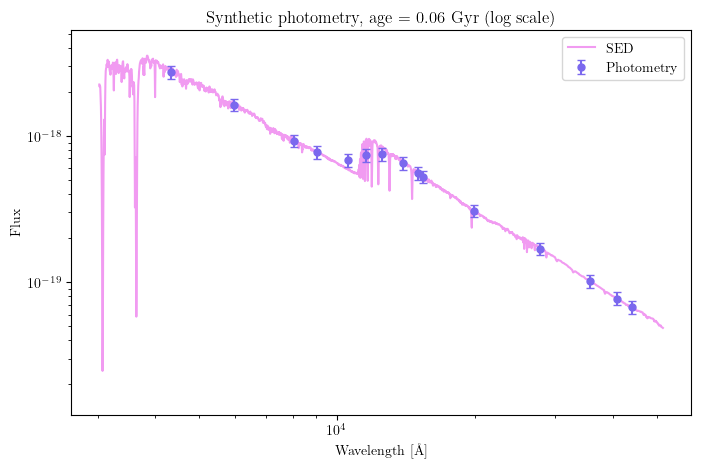

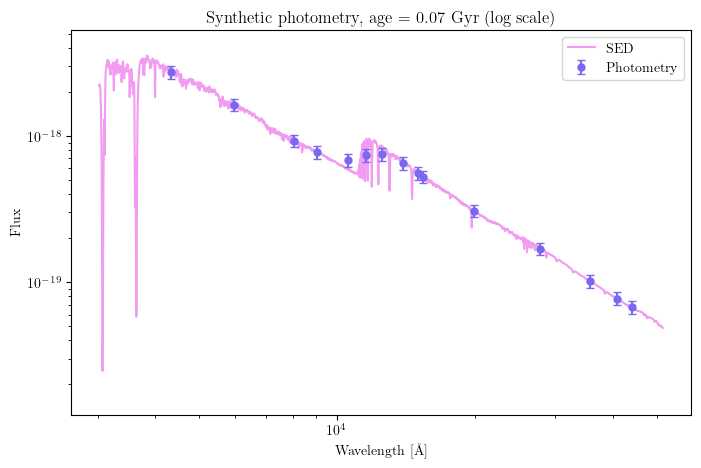

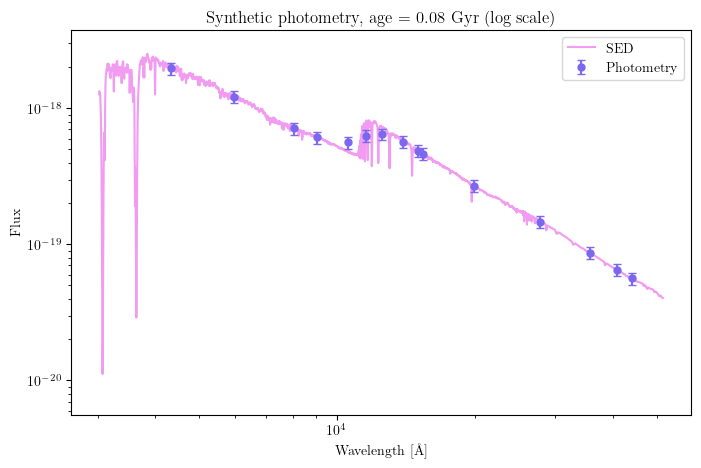

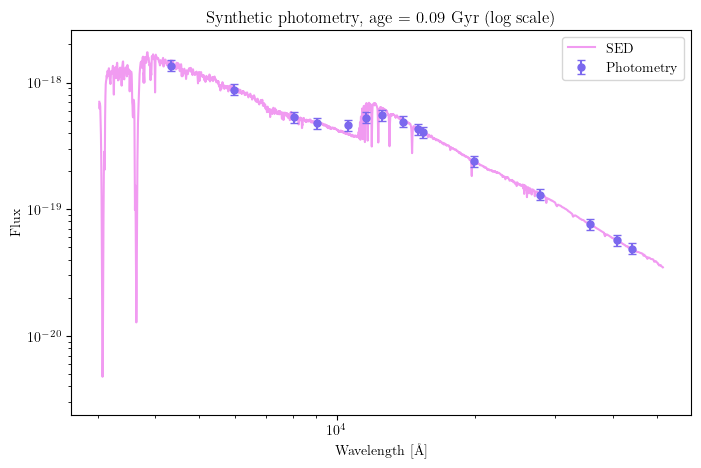

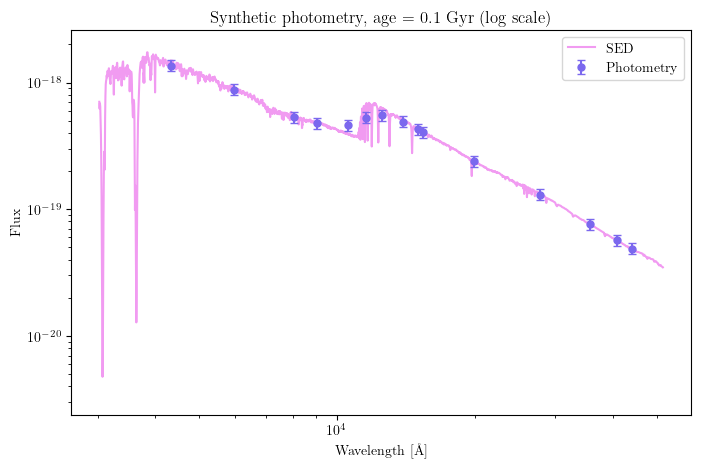

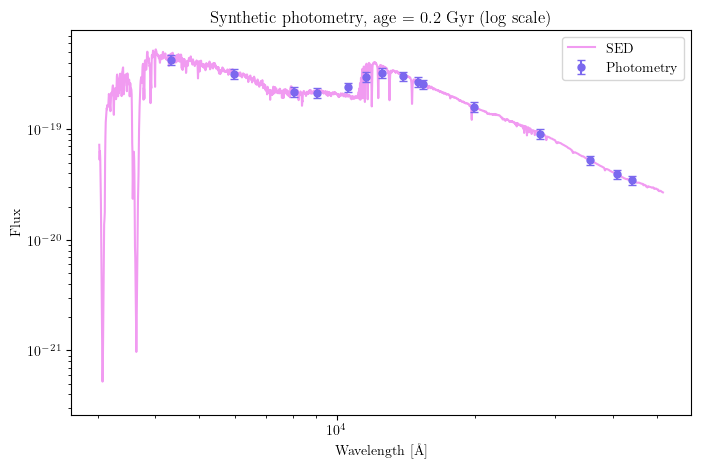

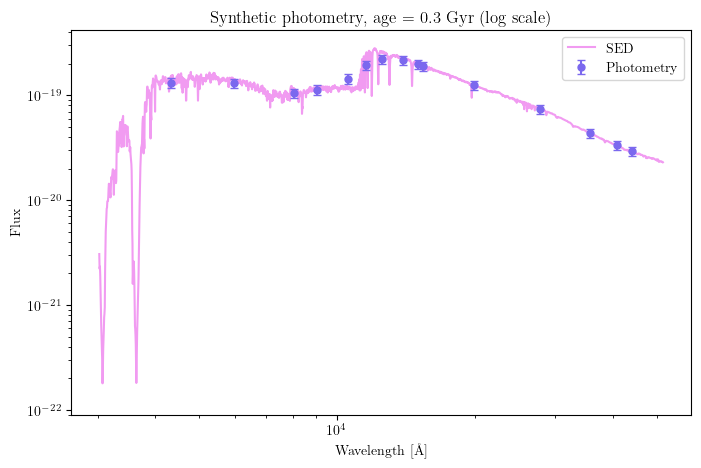

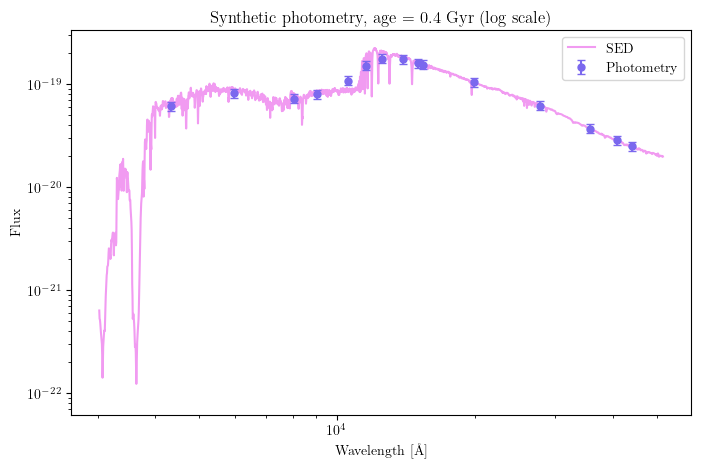

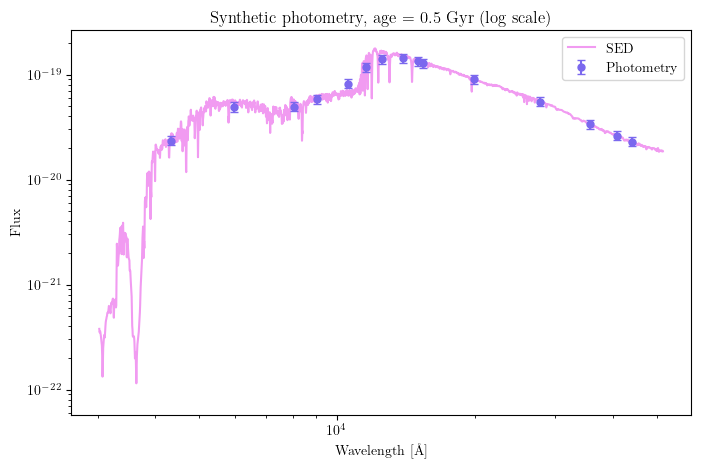

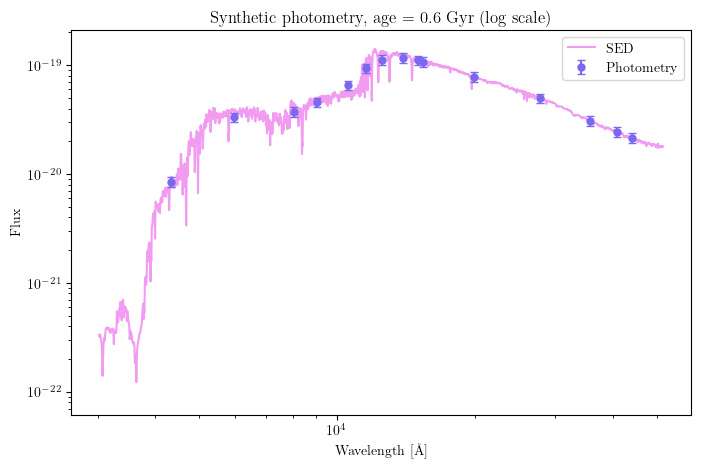

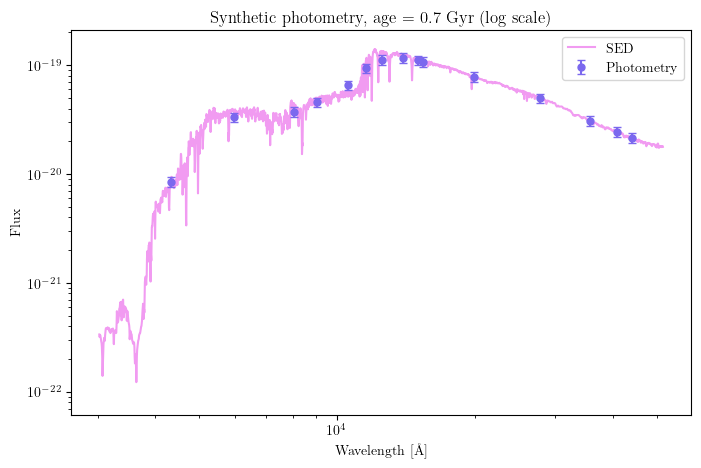

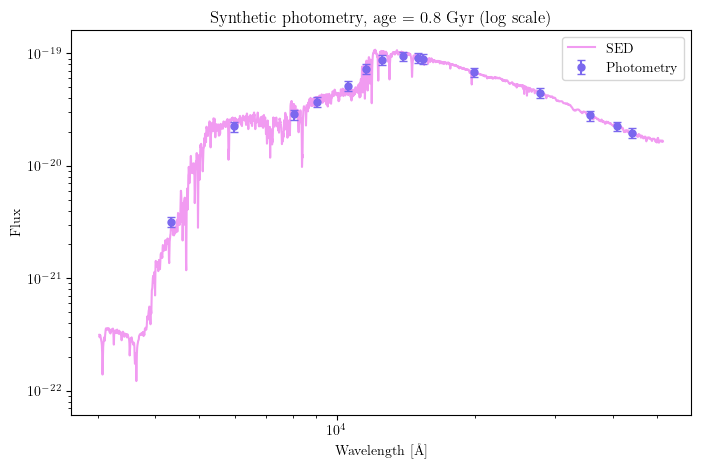

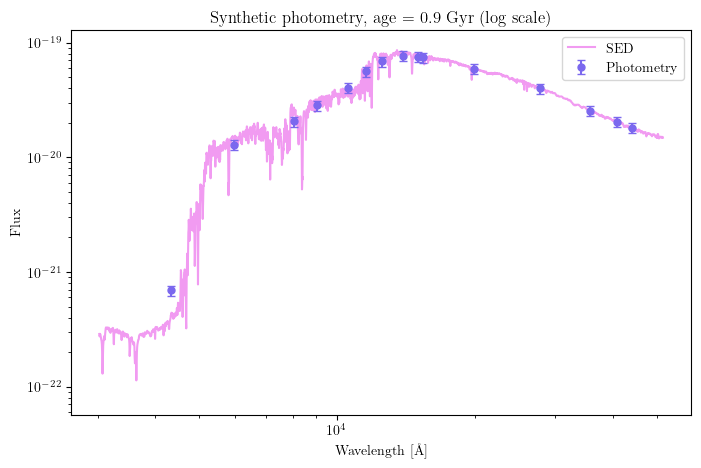

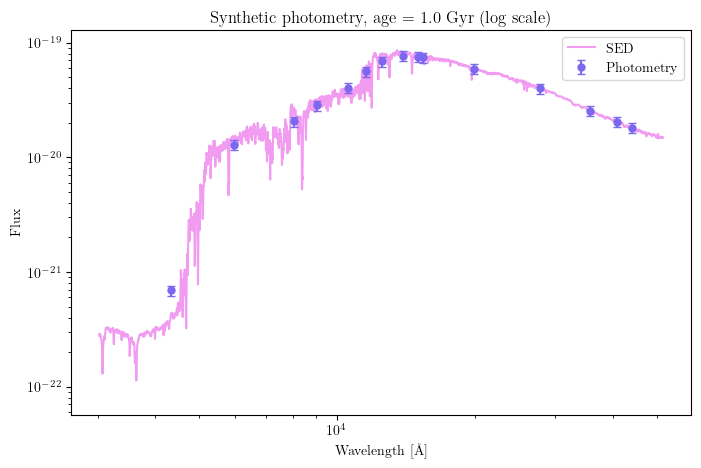

In [6]:

for t in years:

    burst = {
        "age": t,
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 2,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }
    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
       spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    # synthetic photometry
    photometry = model.photometry 
    fluxes = np.array(photometry)

    fluxes_error = fluxes / 10.0

    filter_wavelengths = []

    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:,0]
        transmission = filt_data[:,1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        filter_wavelengths.append(eff_wave)

    filter_wavelengths = np.array(filter_wavelengths)
    photometry = np.array(model.photometry)  # flux in each filter
    y = model.spectrum

    plt.figure(figsize=(8,5))
    plt.errorbar(filter_wavelengths, fluxes, yerr=fluxes_error, fmt='o', ms=5, color='mediumslateblue', elinewidth=1.5, capsize=3, label='Photometry', zorder=5)
    plt.plot(model.spectrum[:,0], model.spectrum[:,1],
         alpha=0.8, color='violet', label='SED', zorder=1)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Flux")
    plt.title(f"Synthetic photometry, age = {t} Gyr (log scale)")
    plt.ylim(y[:,1].min()*0.5, y[:,1].max()*1.5)
    plt.legend()
    plt.show()

In [7]:
galaxy_photometry = np.c_[
    fluxes,
    fluxes_error
]

galaxy = pipes.galaxy(
    "synthetic",                         # arbitrary ID
    lambda ID: galaxy_photometry,        # function returning photometry
    spectrum_exists=False,
    filt_list=filter_files
)

In [8]:
exp = {}                                  # Tau-model star-formation history component
exp["age"] = (0.1, 15.)                   # Vary age between 100 Myr and 15 Gyr. In practice 
                                          # the code automatically limits this to the age of
                                          # the Universe at the observed redshift.

exp["tau"] = (0.3, 10.)                   # Vary tau between 300 Myr and 10 Gyr
exp["massformed"] = (1., 15.)             # vary log_10(M*/M_solar) between 1 and 15
exp["metallicity"] = (0., 2.5)            # vary Z between 0 and 2.5 Z_oldsolar

dust = {}                                 # Dust component
dust["type"] = "Calzetti"                 # Define the shape of the attenuation curve
dust["Av"] = (0., 2.)                     # Vary Av between 0 and 2 magnitudes

fit_instructions = {}                     # The fit instructions dictionary
fit_instructions["redshift"] = (0., 10.)  # Vary observed redshift from 0 to 10
fit_instructions["exponential"] = exp   
fit_instructions["dust"] = dust



In [9]:
fit = pipes.fit(galaxy, fit_instructions)

fit.fit(verbose=False)

MultiNest not available. Switching to nautilus.

Bagpipes: fitting object synthetic



KeyError: "Unable to synchronously open attribute (can't locate attribute: 'rng_state')"

In [ ]:
nebular = {
    "logU": -3.0
}

#exp = {}                                  # Tau-model star-formation history component
#exp["age"] = (0.1, 15.)                   # Vary age between 100 Myr and 15 Gyr. In practice 
                                          # the code automatically limits this to the age of
                                          # the Universe at the observed redshift.

exp["tau"] = (0.3, 10.)                   # Vary tau between 300 Myr and 10 Gyr
exp["massformed"] = (1., 15.)             # vary log_10(M*/M_solar) between 1 and 15
exp["metallicity"] = (0., 2.5)            # vary Z between 0 and 2.5 Z_oldsolar

dust = {}                                 # Dust component
dust["type"] = "Calzetti"                 # Define the shape of the attenuation curve
dust["Av"] = (0., 2.)                     # Vary Av between 0 and 2 magnitudes

fit_instructions = {}                     # The fit instructions dictionary
fit_instructions["redshift"] = (0., 10.)  # Vary observed redshift from 0 to 10
fit_instructions["nebular"] = nebular  
fit_instructions["dust"] = dust


fit = pipes.fit(galaxy, fit_instructions)
fit.fit(verbose=False)

#fit = pipes.fit_model(model, photometry_data, filters)
#fig = fit.plot_spectrum_posterior(save=False, show=True)
#fig = fit.plot_sfh_posterior(save=False, show=True)
#fig = fit.plot_corner(save=False, show=True)

MultiNest not available. Switching to nautilus.

Bagpipes: fitting object synthetic



ValueError: Maxdims is smaller than dims (maxdims is smaller than dims)

In [ ]:
nebular = {}
nebular["logU"] = (-4.0, -1.0)   # allow ionisation parameter to vary

exp = {}
exp["age"] = (0.1, 13.5)         # Gyr (Bagpipes will cap at Universe age)
exp["tau"] = (0.3, 10.)          # Gyr
exp["massformed"] = (1., 15.)    # log10(M*/Msun)
exp["metallicity"] = (0., 2.5)   # Z/Z_solar

dust = {}
dust["type"] = "Calzetti"
dust["Av"] = (0., 2.)

fit_instructions = {}
fit_instructions["redshift"] = (0., 10.)
fit_instructions["exp"] = exp              # <-- this was missing
fit_instructions["dust"] = dust
fit_instructions["nebular"] = nebular      # <-- nebular included here

fit = pipes.fit(galaxy, fit_instructions)
fit.fit(verbose=False)

# Posterior plots
fig1 = fit.plot_spectrum_posterior(show=True)
fig2 = fit.plot_sfh_posterior(show=True)
fig3 = fit.plot_corner(show=True)

MultiNest not available. Switching to nautilus.

Bagpipes: fitting object synthetic



KeyError: "Unable to synchronously open attribute (can't locate attribute: 'rng_state')"